In [1]:
# --- Imports and System Path Setup ---
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Add src/ directory to system path
REPO_PATH = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(REPO_PATH / "src"))

from utils import get_summary_stats
print("Packages and src/utils.py imported successfully.")



Packages and src/utils.py imported successfully.


In [3]:
# --- Load Multi-Header S&P 500 CSV Data ---
data_path = REPO_PATH / "data" / "raw" / "sp500_daily_history.csv"

# Skip the first 3 header/ticker/empty metadata rows
df = pd.read_csv(
    data_path, 
    skiprows=3, 
    header=None, 
    names=['Date', 'Close', 'High', 'Low', 'Open', 'Volume']
)

# Convert Date to datetime format and ensure numeric types
df['Date'] = pd.to_datetime(df['Date'])
print("Dataset Head:")
print(df.head())

print("\nDataset Info:")
df.info()



Dataset Head:
        Date        Close         High          Low         Open      Volume
0 2020-01-02  3257.850098  3258.139893  3235.530029  3244.669922  3459930000
1 2020-01-03  3234.850098  3246.149902  3222.340088  3226.360107  3484700000
2 2020-01-06  3246.280029  3246.840088  3214.639893  3217.550049  3702460000
3 2020-01-07  3237.179932  3244.909912  3232.429932  3241.860107  3435910000
4 2020-01-08  3253.050049  3267.070068  3236.669922  3238.590088  3726840000

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1507 entries, 0 to 1506
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1507 non-null   datetime64[ns]
 1   Close   1507 non-null   float64       
 2   High    1507 non-null   float64       
 3   Low     1507 non-null   float64       
 4   Open    1507 non-null   float64       
 5   Volume  1507 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
mem

In [4]:
# --- Call Custom Utility for Summary Statistics ---
summary_df = get_summary_stats(df)
print("\nS&P 500 Summary Statistics:")
print(summary_df)

# Save processed summary to data/processed/
output_path = REPO_PATH / "data" / "processed" / "sp500_summary_stage03.csv"
output_path.parent.mkdir(parents=True, exist_ok=True)
summary_df.to_csv(output_path)
print(f"\nSaved summary statistics to: {output_path}")




S&P 500 Summary Statistics:
         count          mean           std          min           50%  \
Close   1507.0  4.582586e+03  1.026673e+03  2237.399902  4.380260e+03   
High    1507.0  4.608168e+03  1.026606e+03  2300.729980  4.410310e+03   
Low     1507.0  4.553410e+03  1.026149e+03  2191.860107  4.356290e+03   
Open    1507.0  4.581720e+03  1.026605e+03  2290.709961  4.380940e+03   
Volume  1507.0  4.501056e+09  1.073907e+09     0.000000  4.275630e+09   

                 max  
Close   6.932050e+03  
High    6.945770e+03  
Low     6.921600e+03  
Open    6.936020e+03  
Volume  9.976520e+09  

Saved summary statistics to: /Users/cloudnine_7/bootcamp_elrie_lin/project/data/processed/sp500_summary_stage03.csv


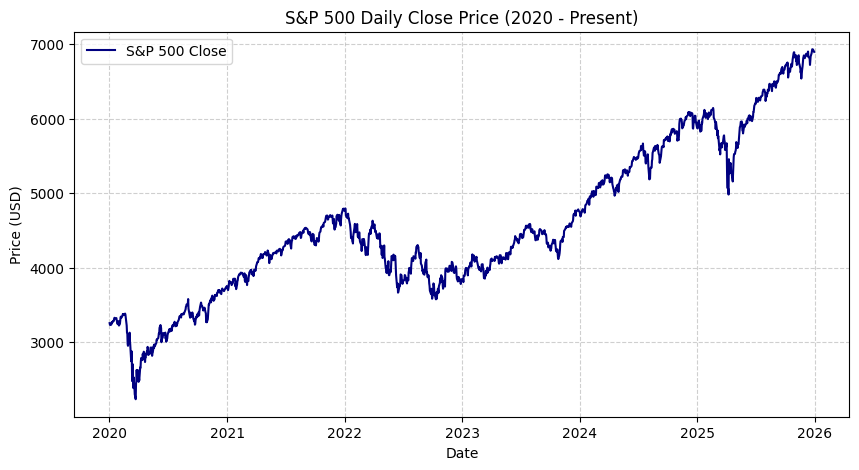

Chart saved to: /Users/cloudnine_7/bootcamp_elrie_lin/project/reports/sp500_close_trend.png


In [6]:
# --- Simple Visual Inspection (Close Price Trend) ---
plt.figure(figsize=(10, 5))
plt.plot(df['Date'], df['Close'], color='navy', label='S&P 500 Close')
plt.title('S&P 500 Daily Close Price (2020 - Present)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Save plot to reports directory
plot_path = REPO_PATH / "reports" / "sp500_close_trend.png"
plot_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Chart saved to: {plot_path}")